# Simple Signal / Spectrum Classifier

We generate synthetic signals (clean, noisy, pure noise), extract FFT-based features, and train simple `scikit-learn` classifiers.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt

from generate_signals import generate_dataset, FS, T
from extract_features import extract_features, FEATURE_NAMES, _spectrum
from model import prepare_data, train_and_evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

## 1. Generate the synthetic dataset

In [2]:
X_time, y, meta = generate_dataset(n_per_class=200)
print(X_time.shape, y.shape)
np.unique(y, return_counts=True)

(600, 500) (600,)


(array(['clean', 'noise', 'noisy'], dtype='<U5'), array([200, 200, 200]))

## 2. Visualize one examnple per class (time domain and spectrum)

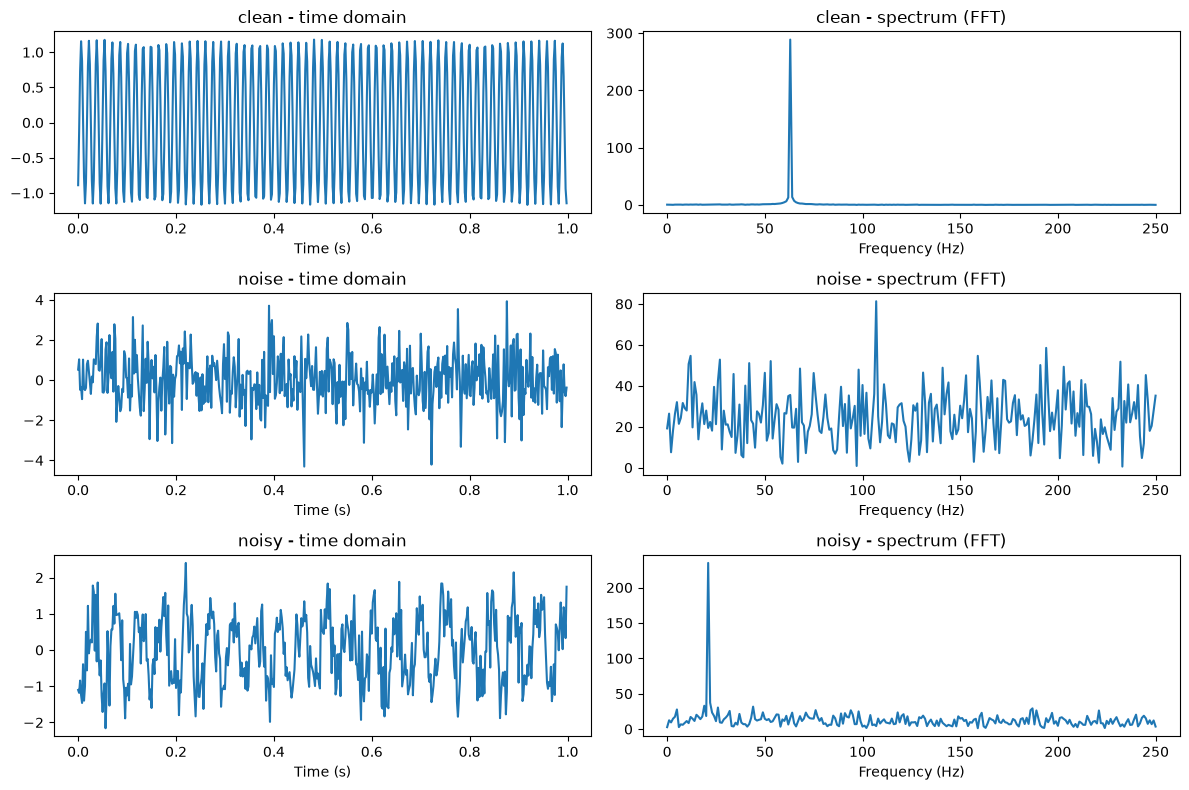

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
unique_classes = np.unique(y)

for i, cls in enumerate(unique_classes):
    idx = np.where(y == cls)[0][0]
    signal = X_time[idx]
    frequencies, magnitudes = _spectrum(signal)

    axes[i, 0].plot(T, signal)
    axes[i, 0].set_title(f'{cls} - time domain')
    axes[i, 0].set_xlabel('Time (s)')

    axes[i, 1].plot(frequencies, magnitudes)
    axes[i, 1].set_title(f'{cls} - spectrum (FFT)')
    axes[i, 1].set_xlabel('Frequency (Hz)')

plt.tight_layout()
plt.savefig('../figures/examples_per_class.png', dpi=120)
plt.show()

## 3. Extract features and train models

In [4]:
X_train, X_test, y_train, y_test, scaler = prepare_data(n_per_class=200)

log_model = LogisticRegression(max_iter=1000)
log_model, y_pred_log = train_and_evaluate(log_model, 'Logistic Regression', X_train, X_test, y_train, y_test)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model, y_pred_tree = train_and_evaluate(tree_model, 'Decision Tree', X_train, X_test, y_train, y_test)


Model: Logistic Regression
              precision    recall  f1-score   support

       clean       0.65      0.66      0.65        50
       noise       1.00      1.00      1.00        50
       noisy       0.65      0.64      0.65        50

    accuracy                           0.77       150
   macro avg       0.77      0.77      0.77       150
weighted avg       0.77      0.77      0.77       150

Confusion matrix:
[[33  0 17]
 [ 0 50  0]
 [18  0 32]]

Model: Decision Tree
              precision    recall  f1-score   support

       clean       0.62      0.92      0.74        50
       noise       1.00      1.00      1.00        50
       noisy       0.85      0.44      0.58        50

    accuracy                           0.79       150
   macro avg       0.82      0.79      0.77       150
weighted avg       0.82      0.79      0.77       150

Confusion matrix:
[[46  0  4]
 [ 0 50  0]
 [28  0 22]]


## 4. Feature importance

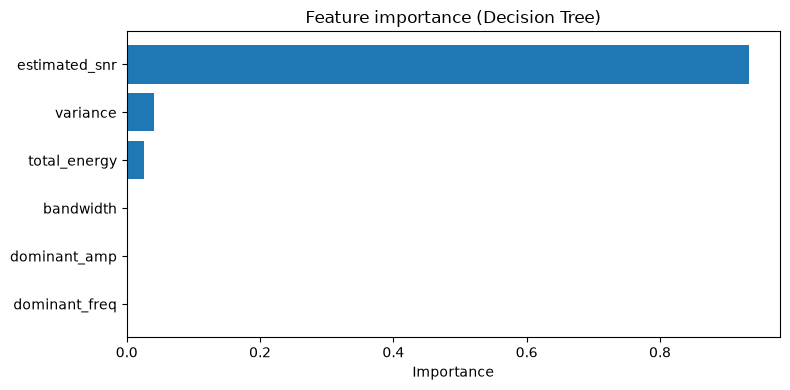

In [5]:
importances = tree_model.feature_importances_
order = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(np.array(FEATURE_NAMES)[order], importances[order])
plt.xlabel('Importance')
plt.title('Feature importance (Decision Tree)')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=120)
plt.show()

## 5. Conclusions

- The pure `noise` class is perfectly separated from the other two.
- The main confusion happens between `clean` and `noisy` at intermediate SNR, which is physically expected.
- The most relevant feature is `estimated_snr`, followed by `variance` and `total_energy`.